In [41]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict


In [42]:
class State_Schema(TypedDict):
    score:int 
    balls:int 
    fours:int  
    sixes:int   

    balls_per_boundary:float    
    strike_rate:float   
    boundary_percentage:float   

    

In [43]:
graph = StateGraph(State_Schema)


In [44]:
def balls_per_boundary(state:State_Schema):
    bpb = state['balls']/(state['fours']+state['sixes'])

    return {'balls_per_boundary':round(bpb,2)}




In [45]:
def strike_rate(state:State_Schema):
    str_rate = state['score']/(state['balls'])*100

    return {'strike_rate':round(str_rate,2)}

In [46]:
def boundary_percentage(state:State_Schema):
    bp = ((state['fours']*4)+(state['sixes']*6))/(state['score'])*100

    return {'boundary_percentage':round(bp,2)}

In [47]:
def summary(state:State_Schema):
    return state

In [48]:

#add nodes 
graph.add_node('balls_per_boundary',balls_per_boundary)
graph.add_node('strike_rate',strike_rate)
graph.add_node('boundary_percentage',boundary_percentage)
graph.add_node('summary',summary)

# add edges
graph.add_edge(START , 'balls_per_boundary')
graph.add_edge(START , 'strike_rate')
graph.add_edge(START , 'boundary_percentage')

graph.add_edge('balls_per_boundary','summary')
graph.add_edge('strike_rate','summary')
graph.add_edge('boundary_percentage','summary')
graph.add_edge('summary',END)

#compile graph
workflow = graph.compile()

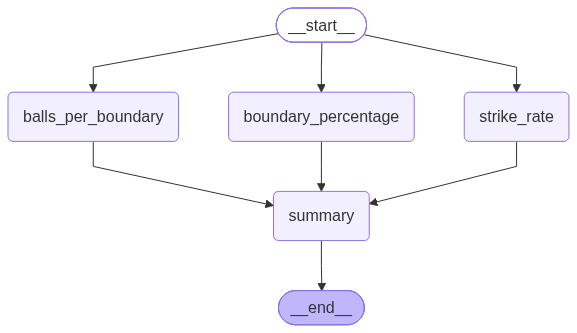

In [49]:
workflow

In [50]:
intial_state = {
    'score':264 ,
'balls':137,
'fours':26,
'sixes':20
}

res = workflow.invoke(intial_state)

print(res)

{'score': 264, 'balls': 137, 'fours': 26, 'sixes': 20, 'balls_per_boundary': 2.98, 'strike_rate': 192.7, 'boundary_percentage': 84.85}
